# Sieci neuronowe i Deep Learning
# Temat 6: PyTorch dla bardziej zaawansowanych

## Zadanie 6.1

Na przykładzie problemu XOR porównać działanie sieci MLP o różnych architekturach (o różnej głębokości i szerokości).

- Przeanalizować, co się dzieje, gdy dokładamy kolejne warstwy ukryte (jedną, dwie, trzy i cztery) o tej samej wielkości, na przykład z 4, 10 neuronami.

- Przeanalizować, co się dzieje, gdy zwiększamy szerokość ukrytych warstw (dla jednej ukrytej warstwy i dla dwóch ukrytych warstw).

- Przy której ze strategii będziemy w stanie osiągać dobre wyniki predykcyjne dla możliwie małej (o małej liczbie parametrów) sieci neuronowej?

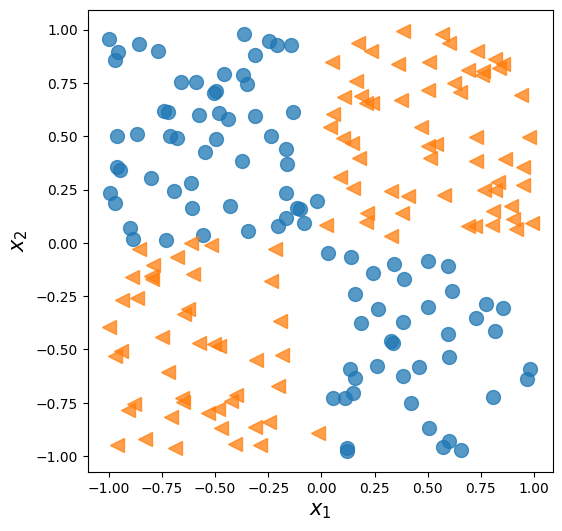

In [ ]:
import torch

import numpy as np
import matplotlib.pyplot as plt


np.random.seed(1)
torch.manual_seed(1)
x = np.random.uniform(low=-1, high=1, size=(200, 2))
y = np.ones(len(x))
y[x[:, 0] * x[:, 1]<0] = 0

n_train = 100
x_train = torch.tensor(x[:n_train, :], dtype=torch.float32)
y_train = torch.tensor(y[:n_train], dtype=torch.float32)
x_valid = torch.tensor(x[n_train:, :], dtype=torch.float32)
y_valid = torch.tensor(y[n_train:], dtype=torch.float32)

fig = plt.figure(figsize=(6, 6))
plt.plot(x[y==0, 0],
         x[y==0, 1], 'o', alpha=0.75, markersize=10)
plt.plot(x[y==1, 0],
         x[y==1, 1], '<', alpha=0.75, markersize=10)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)

plt.show()

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

train_ds = TensorDataset(x_train, y_train)
batch_size = 2
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [ ]:
import torch.nn as nn


In [ ]:

def train(model, num_epochs, train_dl, x_valid, y_valid, optimizer):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs

    for epoch in range(num_epochs):
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            loss_hist_train[epoch] += loss.item()
            is_correct = ((pred>=0.5).float() == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.mean()

        loss_hist_train[epoch] /= n_train/batch_size
        accuracy_hist_train[epoch] /= n_train/batch_size

        pred = model(x_valid)[:, 0]
        loss = loss_fn(pred, y_valid)
        loss_hist_valid[epoch] = loss.item()
        is_correct = ((pred>=0.5).float() == y_valid).float()
        accuracy_hist_valid[epoch] += is_correct.mean()
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid


def XOR(model, num_epochs, train_dl, optimizer):
  history = train(model, num_epochs, train_dl, x_valid, y_valid, optimizer)
  fig = plt.figure(figsize=(16, 4))
  ax = fig.add_subplot(1, 2, 1)
  plt.plot(history[0], lw=4)
  plt.plot(history[1], lw=4)
  plt.legend(['Train loss', 'Validation loss'], fontsize=15)
  ax.set_xlabel('Epochs', size=15)

  ax = fig.add_subplot(1, 2, 2)
  plt.plot(history[2], lw=4)
  plt.plot(history[3], lw=4)
  plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
  ax.set_xlabel('Epochs', size=15)
  plt.show()

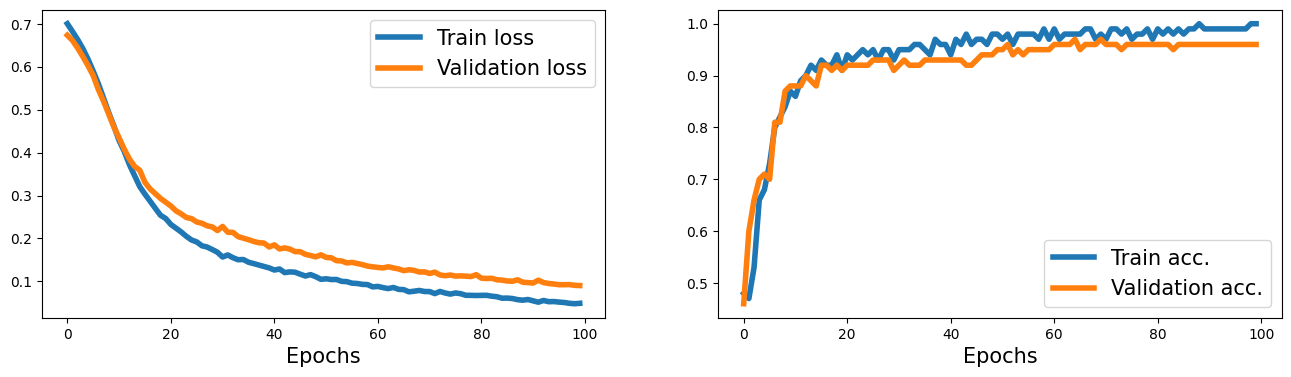

Łączna liczba parametrów: 17


In [ ]:
model= nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)
optimizer = torch.optim.SGD(model.parameters(), lr=0.055)
XOR(model, 100, train_dl, optimizer)
loss_fn = nn.BCELoss()

total_params = sum(p.numel() for p in model.parameters())
print(f"Łączna liczba parametrów: {total_params}")

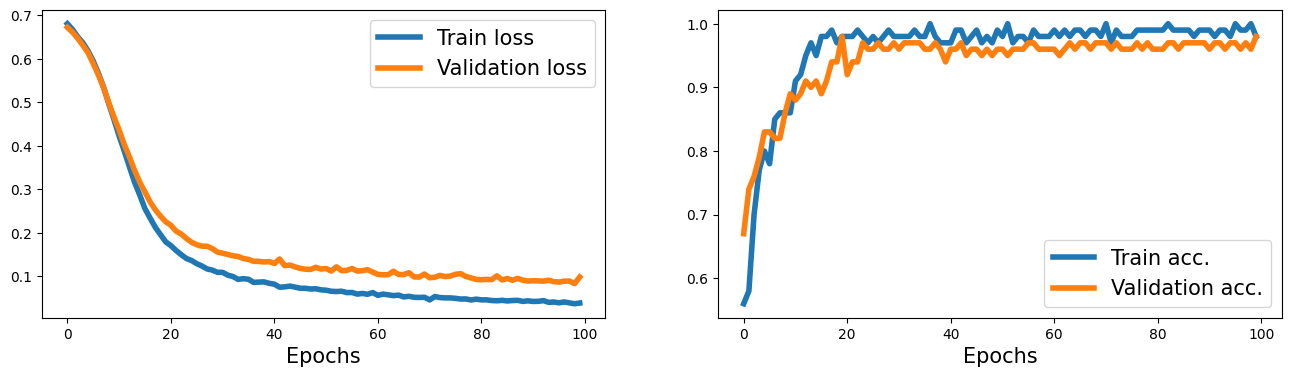

Łączna liczba parametrów: 25


In [ ]:
model1= nn.Sequential(
    nn.Linear(2, 6),
    nn.ReLU(),
    nn.Linear(6, 1),
    nn.Sigmoid()
)
optimizer1 = torch.optim.SGD(model1.parameters(), lr=0.065)
XOR(model1, 100, train_dl, optimizer1)
total_params = sum(p.numel() for p in model1.parameters())
print(f"Łączna liczba parametrów: {total_params}")

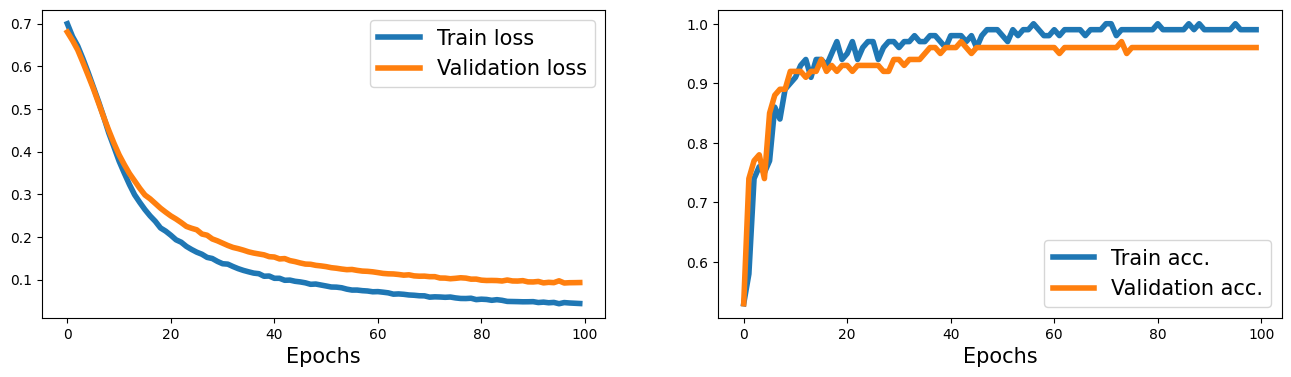

Łączna liczba parametrów: 41


In [ ]:
model2= nn.Sequential(
    nn.Linear(2, 10),
    nn.ReLU(),
    nn.Linear(10, 1),
    nn.Sigmoid()
)
optimizer2 = torch.optim.SGD(model2.parameters(), lr=0.055)
XOR(model2, 100, train_dl, optimizer2)
total_params = sum(p.numel() for p in model2.parameters())
print(f"Łączna liczba parametrów: {total_params}")

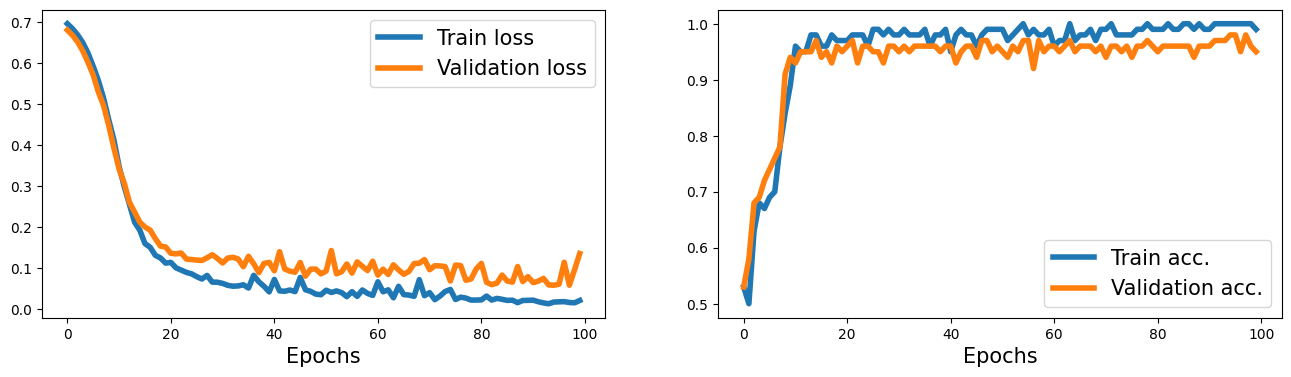

Łączna liczba parametrów: 151


In [ ]:
model3= nn.Sequential(
    nn.Linear(2, 10),
    nn.ReLU(),
    nn.Linear(10, 10),
    nn.ReLU(),
    nn.Linear(10, 1),
    nn.Sigmoid()
)
optimizer3 = torch.optim.SGD(model3.parameters(), lr=0.050)
XOR(model3, 100, train_dl, optimizer3)
total_params = sum(p.numel() for p in model3.parameters())
print(f"Łączna liczba parametrów: {total_params}")

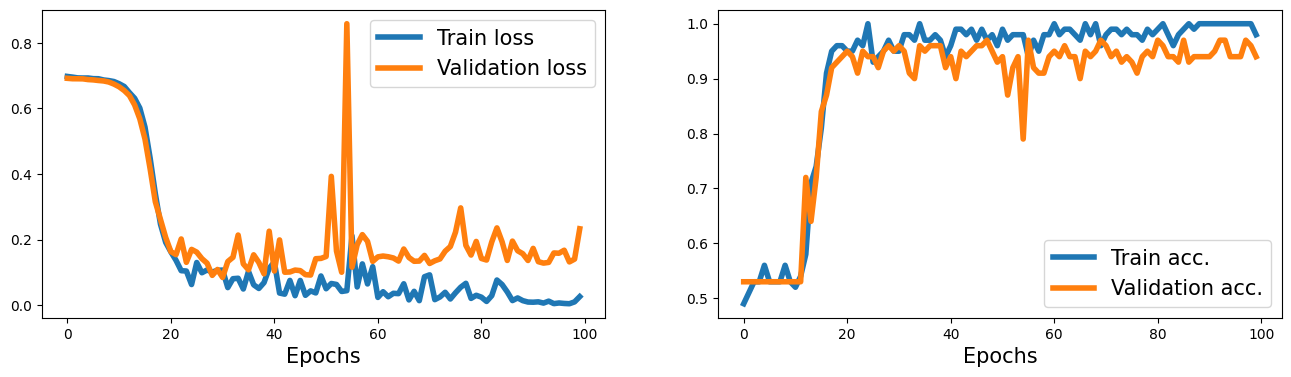

Łączna liczba parametrów: 261


In [ ]:
model4= nn.Sequential(
    nn.Linear(2, 10),
    nn.ReLU(),
    nn.Linear(10, 10),
    nn.ReLU(),
    nn.Linear(10, 10),
    nn.ReLU(),
    nn.Linear(10, 1),
    nn.Sigmoid()
)
optimizer4 = torch.optim.SGD(model4.parameters(), lr=0.050)
XOR(model4, 100, train_dl, optimizer4)
total_params = sum(p.numel() for p in model4.parameters())
print(f"Łączna liczba parametrów: {total_params}")

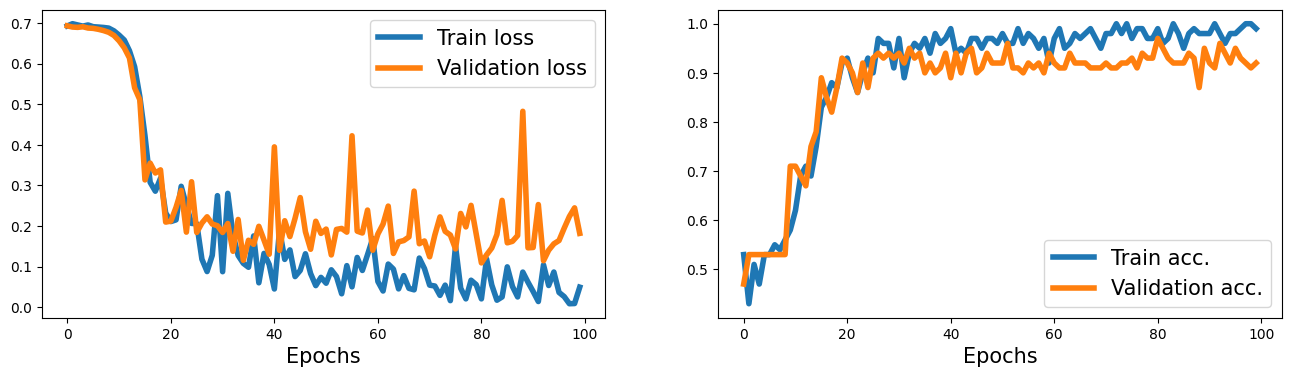

Łączna liczba parametrów: 371


In [ ]:
model5= nn.Sequential(
    nn.Linear(2, 10),
    nn.ReLU(),
    nn.Linear(10, 10),
    nn.ReLU(),
    nn.Linear(10, 10),
    nn.ReLU(),
    nn.Linear(10, 10),
    nn.ReLU(),
    nn.Linear(10, 1),
    nn.Sigmoid()
)
optimizer5 = torch.optim.SGD(model5.parameters(), lr=0.070)
XOR(model5, 100, train_dl, optimizer5)
total_params = sum(p.numel() for p in model5.parameters())
print(f"Łączna liczba parametrów: {total_params}")


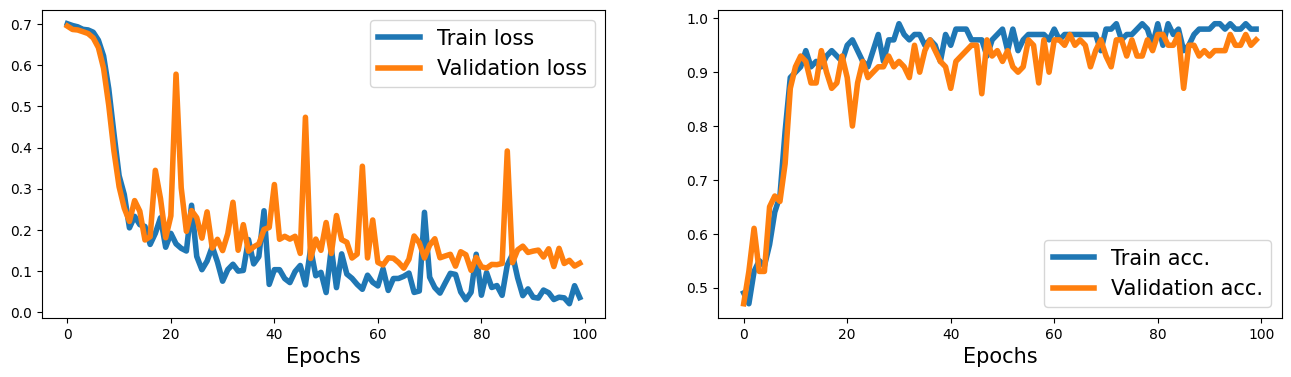

Łączna liczba parametrów: 111


In [ ]:
model6=nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4,10),
    nn.ReLU(),
    nn.Linear(10,4),
    nn.ReLU(),
    nn.Linear(4,1),
    nn.Sigmoid()
 )
optimizer6 = torch.optim.SGD(model6.parameters(), lr=0.07)
XOR(model6, 100, train_dl, optimizer6)
total_params = sum(p.numel() for p in model6.parameters())
print(f"Łączna liczba parametrów: {total_params}")

## Zadanie 6.2*

Wykorzystując klasę `nn.Module`,
zdefiniować niestandardową warstwę, która mnoży dane wejściowe przez stałą wartość (skalowanie), która jest (uczonym) parametrem modelu.

Zmodyfikować wybraną sieć (z tych zbudowanych podczas jednych z poprzednich zajęć), uwzględniając w niej zdefiniowaną warstwę.